# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data, preprocess_data_stress

# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [2]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [3]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)
X_stress = preprocess_data_stress(df_behavior, condition="AROUSING")
X_neurtal = preprocess_data_stress(df_behavior, condition="NEUTRAL")

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)
X_stress_train, X_stress_test = train_test_split(X_stress, test_size=0.4, random_state=42)
X_neutral_train, X_neutral_test = train_test_split(X_neurtal, test_size=0.4, random_state=42)

# Training

In [5]:
from train import (train_feed_forward_nn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.06099758669734001
Epoch 100, Loss: 0.0456826277077198
Epoch 200, Loss: 0.043902263045310974
Epoch 300, Loss: 0.042161088436841965
Epoch 400, Loss: 0.04083259403705597
Epoch 500, Loss: 0.03990250825881958
Epoch 600, Loss: 0.03938593342900276
Epoch 700, Loss: 0.03914180025458336
Epoch 800, Loss: 0.03864865005016327
Epoch 900, Loss: 0.038707781583070755
Epoch 1000, Loss: 0.03874662518501282
Epoch 1100, Loss: 0.03806837648153305
Epoch 1200, Loss: 0.03824716806411743
Epoch 1300, Loss: 0.037809327244758606
Epoch 1400, Loss: 0.03710543364286423
Epoch 1500, Loss: 0.03766686096787453
Epoch 1600, Loss: 0.03690245747566223
Epoch 1700, Loss: 0.03720775246620178
Epoch 1800, Loss: 0.036901067942380905
Epoch 1900, Loss: 0.03632136806845665
Training complete!
Evaluating Model: FeedForwardNN


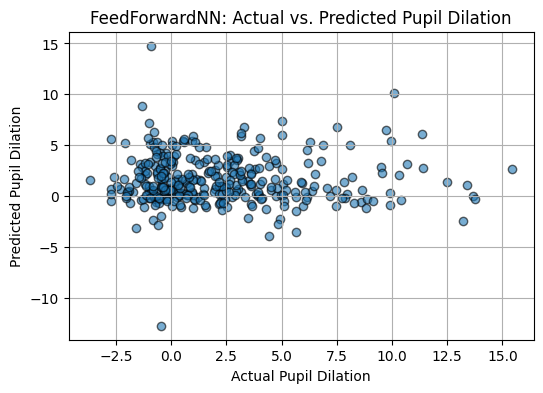

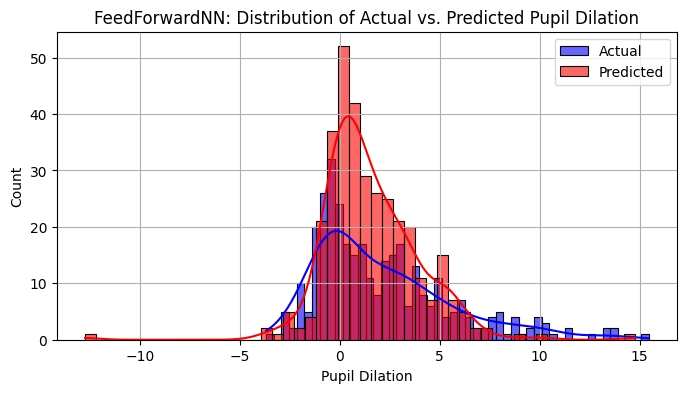

FeedForwardNN - Pearson Correlation: -0.0148


In [6]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [7]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [8]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

In [9]:
# model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
# evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [10]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

Epoch 0, Loss: 0.127013


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.024957
Epoch 200, Loss: 0.017000
Early stopping triggered at epoch 252
Training complete!
Evaluating Model: FFGadgetController


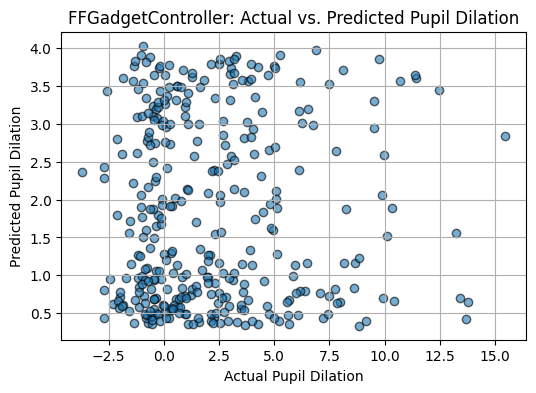

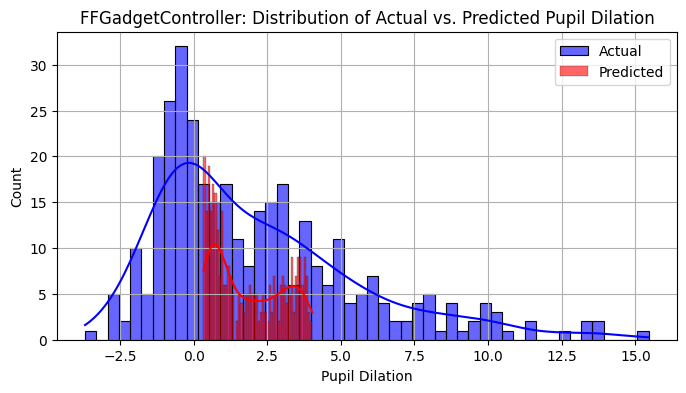

FFGadgetController - Pearson Correlation: 0.0268


In [11]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=124, patience=200)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

Epoch 0, Loss: 0.587220


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.045075
Epoch 200, Loss: 0.049922
Epoch 300, Loss: 0.060227
Epoch 400, Loss: 0.047768
Epoch 500, Loss: 0.051682
Early stopping triggered at epoch 524
Training complete!


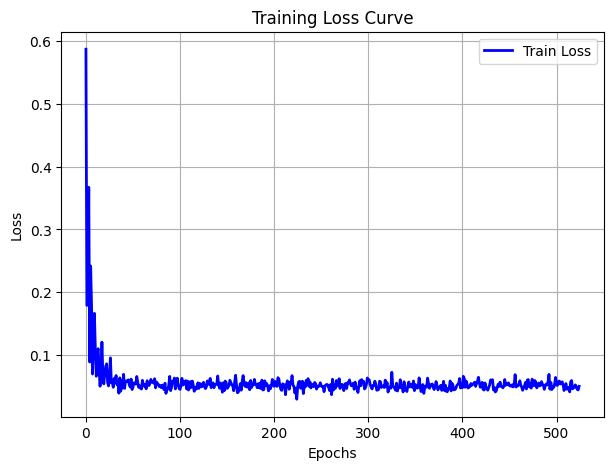

Evaluating Model: FFGadgetUncertainController
Adjusting prev_LC size: torch.Size([256, 256]) -> torch.Size([340, 256])


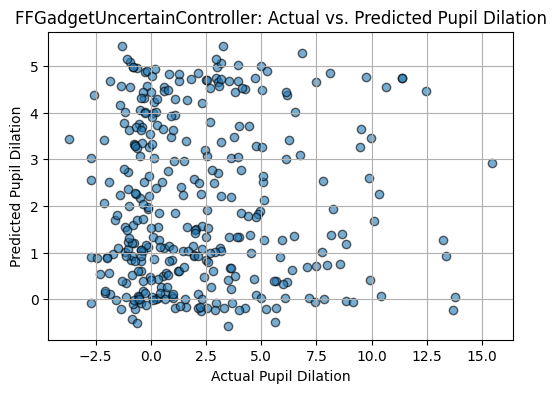

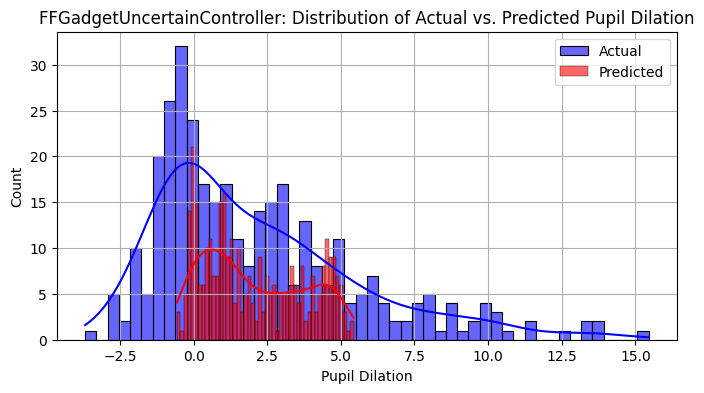

FFGadgetUncertainController - Pearson Correlation: 0.0098


In [12]:
# ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300)
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=1000, hidden_dim=256, batch_size=256, patience=300, entropy_scale=0.5)
evaluate_model(ff_uncertain_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# Analysis

In [13]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [14]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

In [15]:
# with torch.no_grad():
#     prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
#     prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

#     LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

# act_lc = LC_act.cpu().numpy()
# act_ne = NE_act.cpu().numpy()
# act_cortex = C_act.cpu().numpy()

# df_activations = pd.DataFrame({
#     'LC_Mean': act_lc.mean(axis=1),
#     'NE_Mean': act_ne.mean(axis=1),
#     'Cortex_Mean': act_cortex.mean(axis=1),
#     'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
#     'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
# })

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 3, 1)
# sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
# plt.title("LC Activation Distribution")

# plt.subplot(1, 3, 2)
# sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
# plt.title("NE Activation Distribution")

# plt.subplot(1, 3, 3)
# sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
# plt.title("Cortex Activation Distribution")

In [16]:
# pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [17]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [18]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

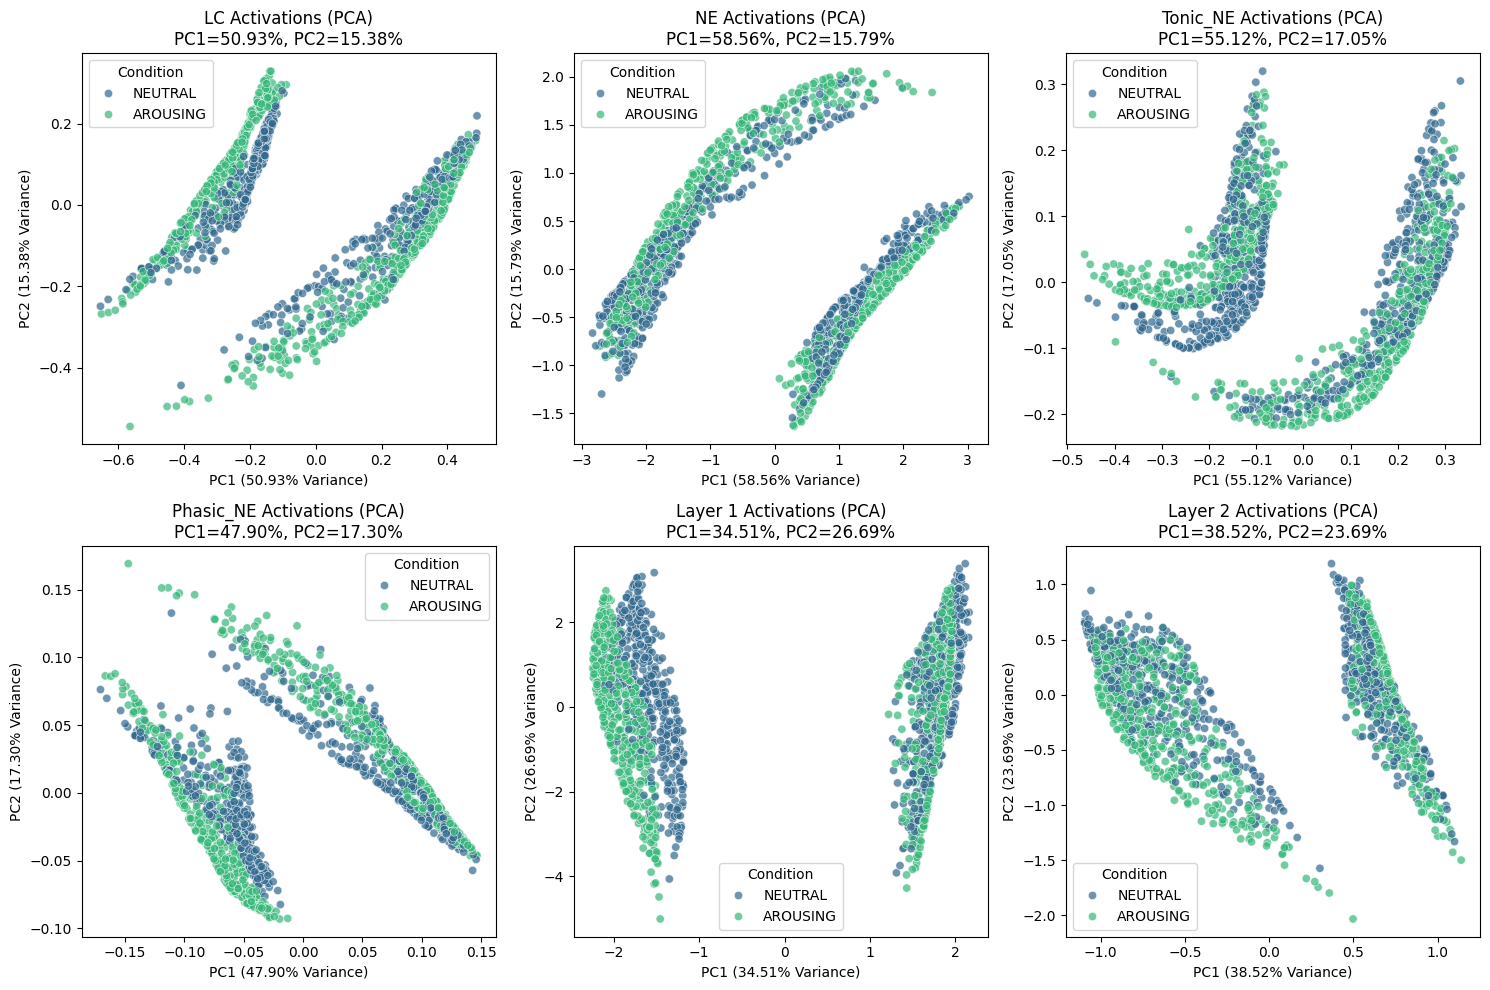

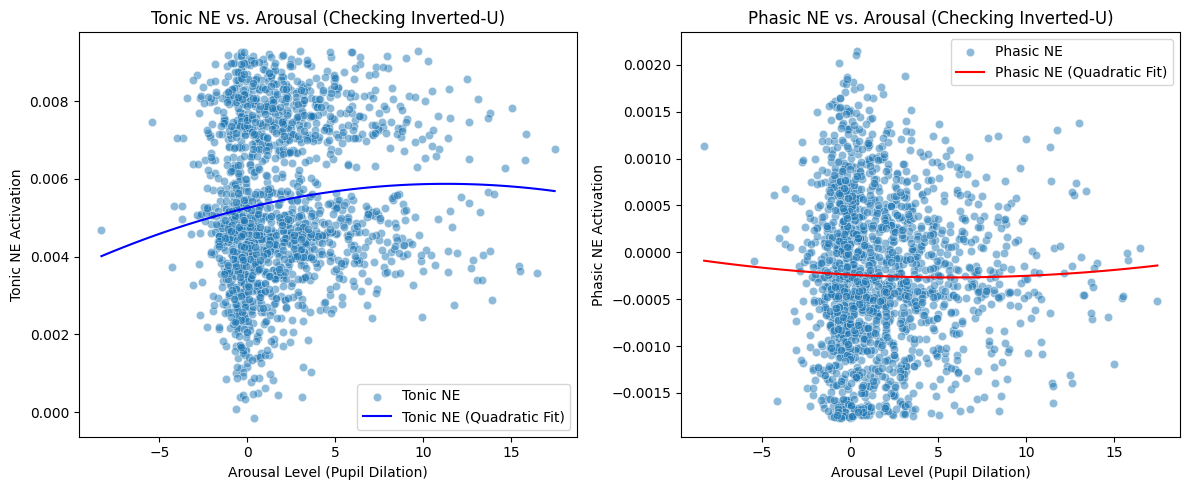


 Pearson Correlation with Actual Pupil Dilation:
LC: -0.269
NE: -0.284
Tonic_NE: 0.111
Phasic_NE: -0.011
Layer 1: 0.162
Layer 2: 0.044
Predicted Pupil Dilation: 0.454


In [19]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])
Pupil Dilation MAE: 2.2023
Pupil Dilation MSE: 8.4614


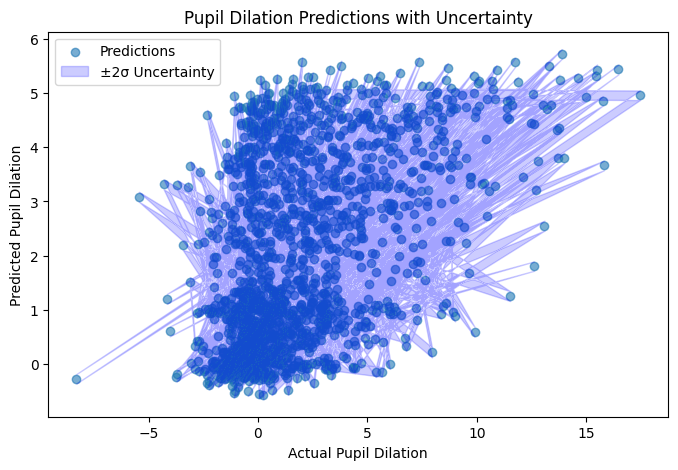

In [20]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [21]:
from analysis.analysis import (extract_activations_gadget,
                               compute_mapper_graph,
                               compute_persistent_homology,
                               compute_persistent_homology_overlay,
                               compute_mapper_graph_overlay)

Persistent homology seems to work with the `uncertainty` model but not other models.

Analyzing LC activations...


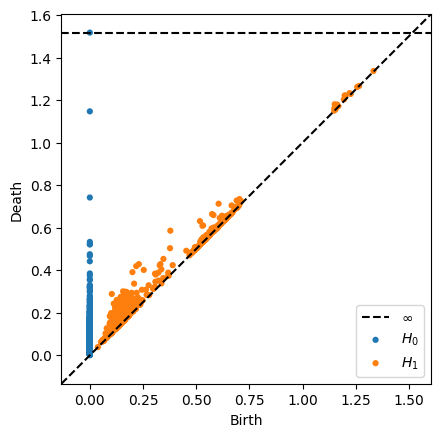

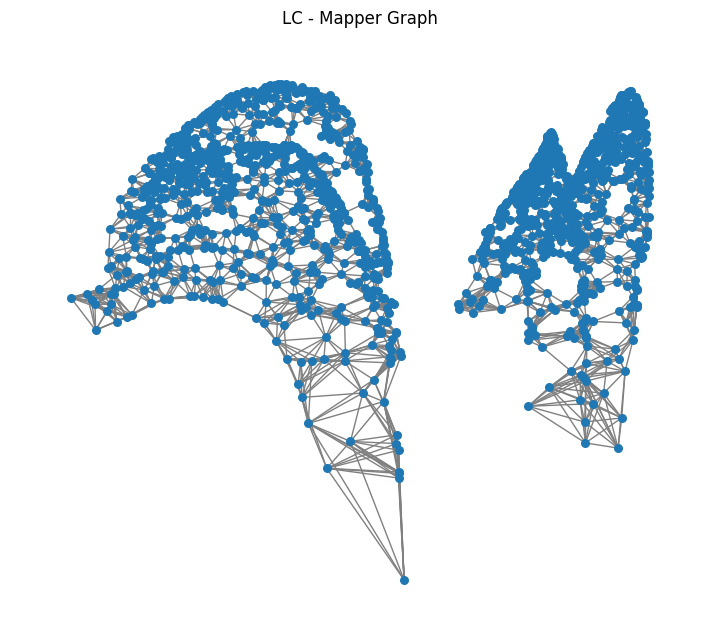

Analyzing NE activations...


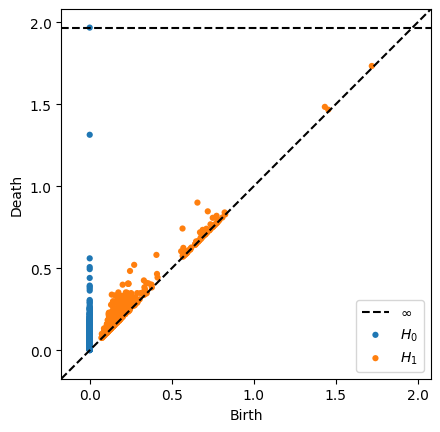

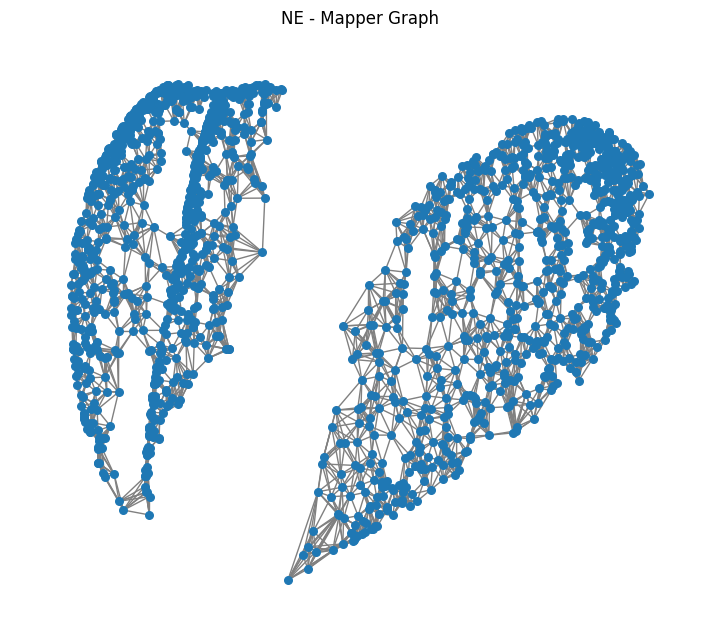

Analyzing Tonic_NE activations...


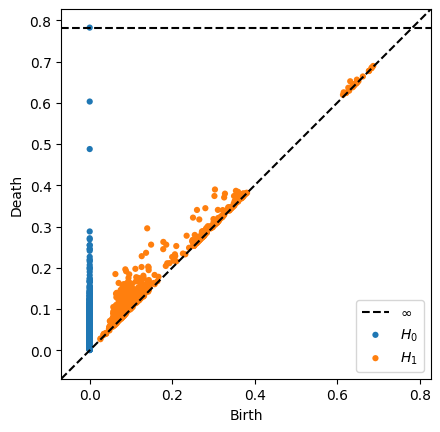

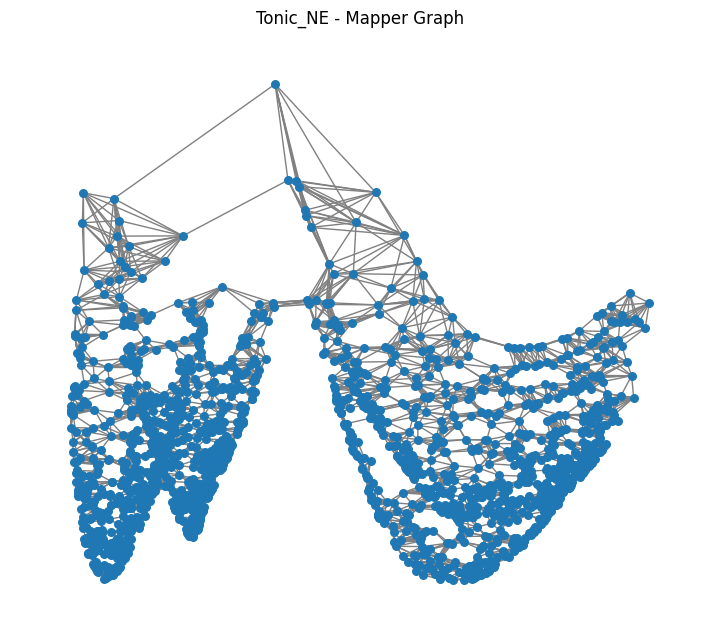

Analyzing Phasic_NE activations...


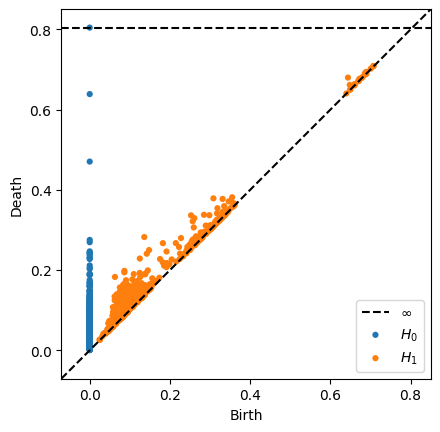

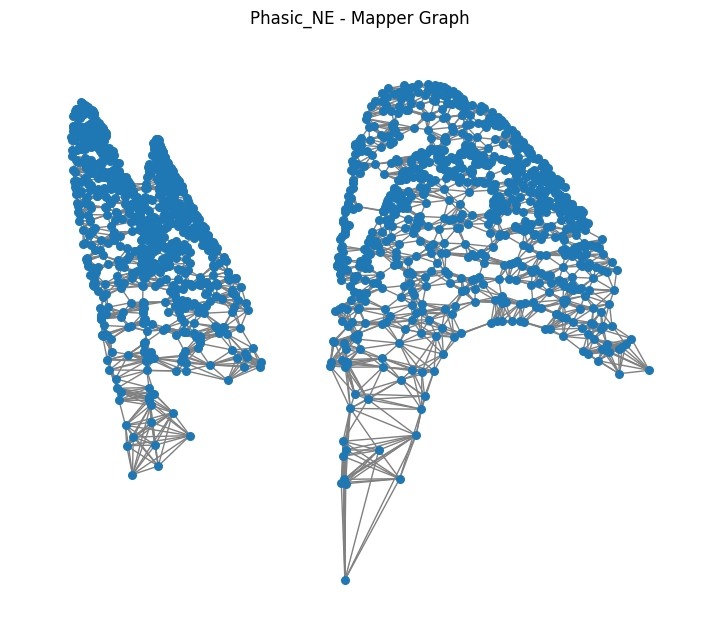

Analyzing Hidden_1 activations...


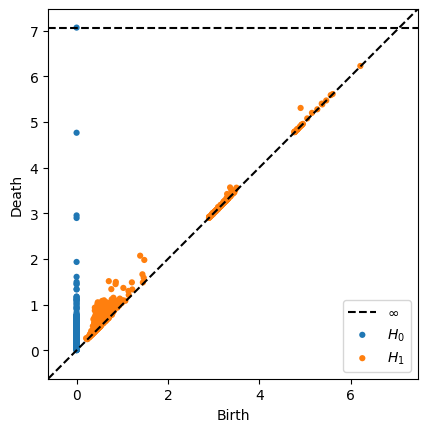

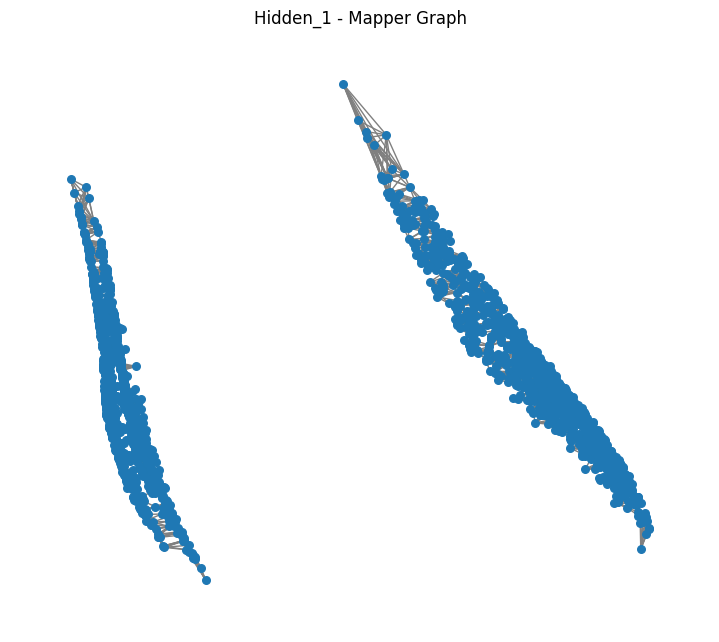

Analyzing Hidden_2 activations...


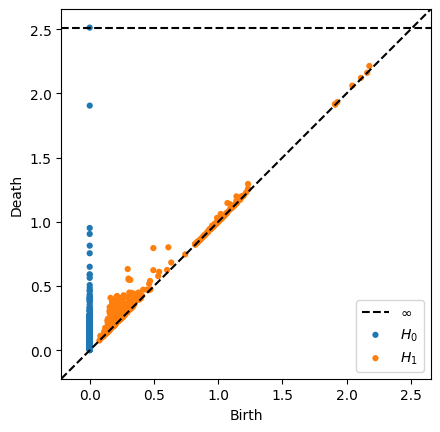

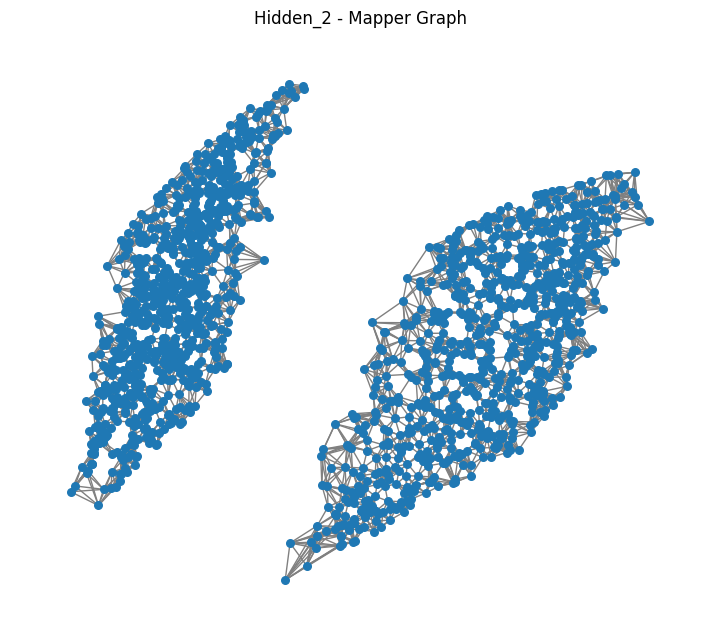

In [22]:
activations = extract_activations_gadget(ff_uncertain_gadget, X_tensor)
# activations = extract_activations_ff_uncertain_gadget(ff_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([341, 256])
Adjusting prev_LC size: torch.Size([341, 256]) -> torch.Size([340, 256])
Analyzing LC activations...


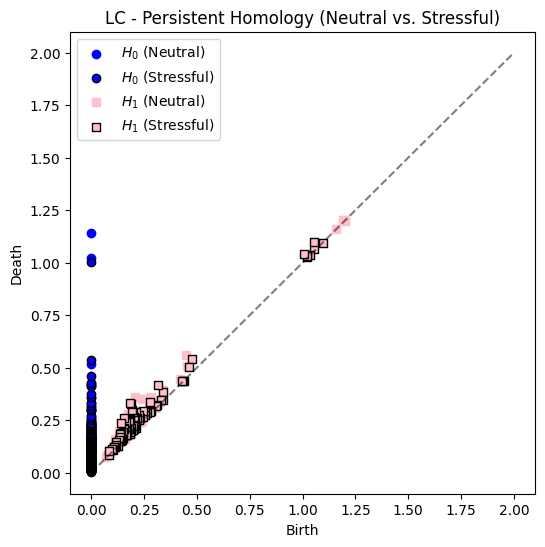

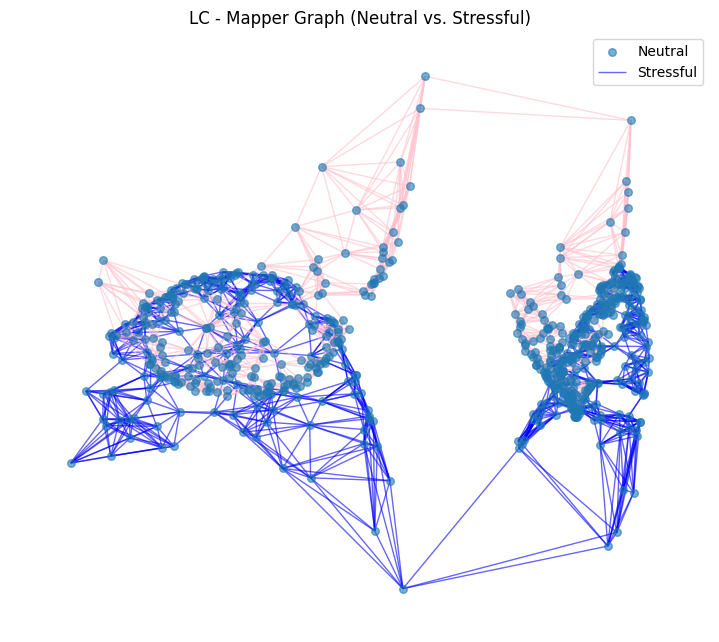

Analyzing NE activations...


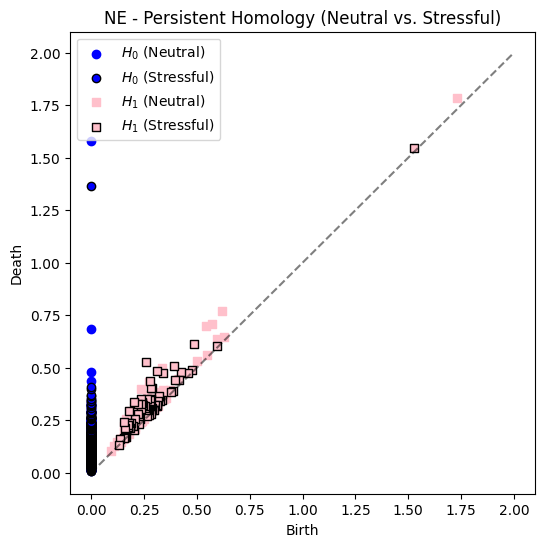

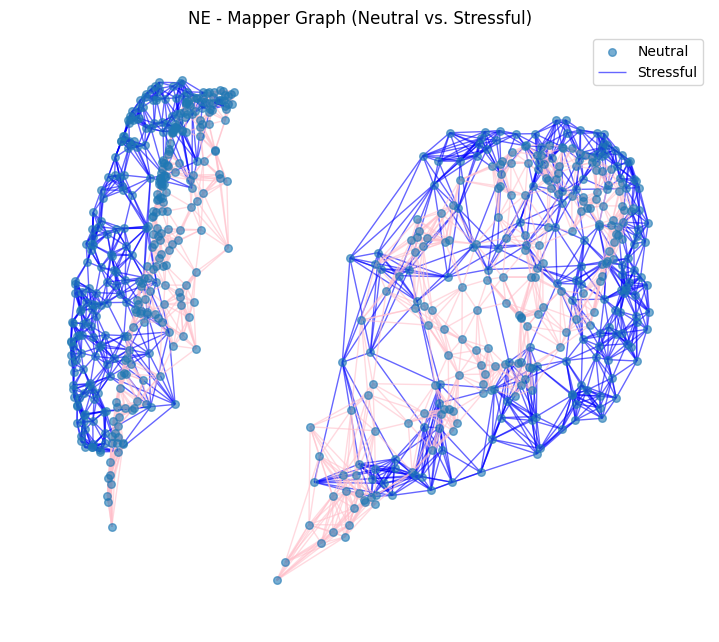

Analyzing Tonic_NE activations...


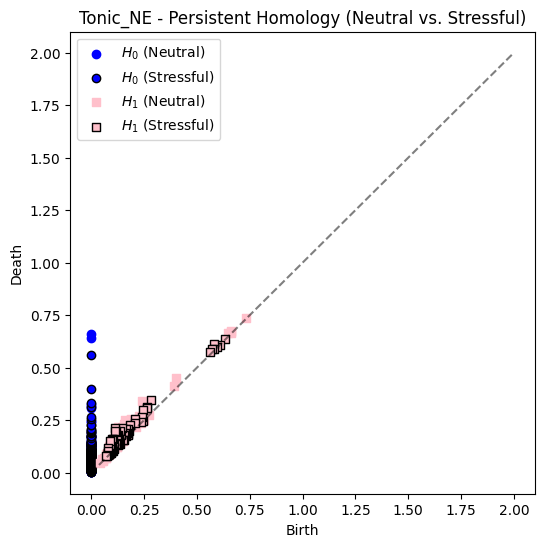

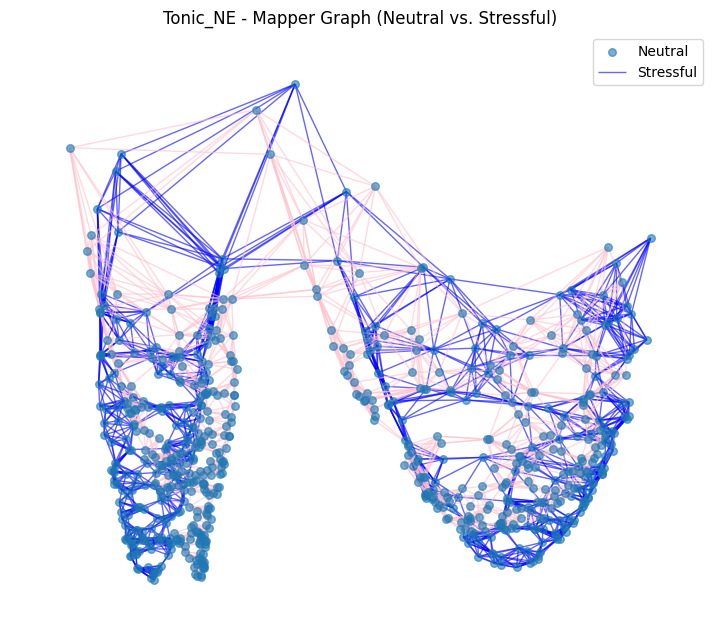

Analyzing Phasic_NE activations...


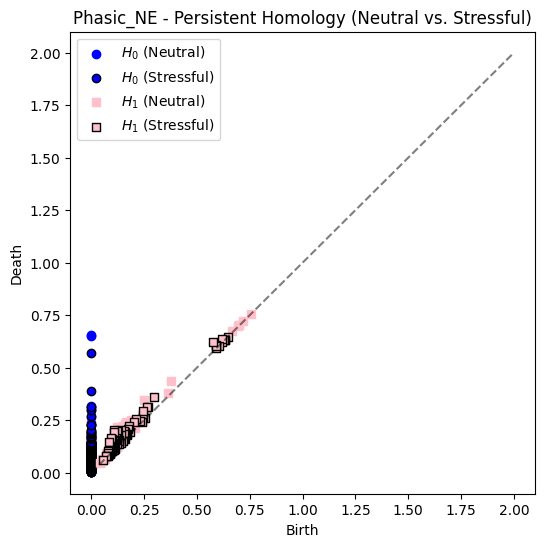

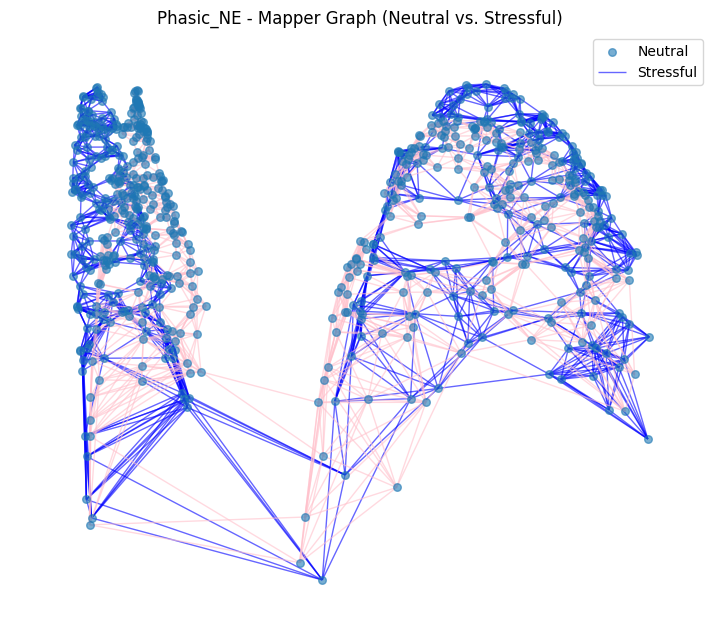

Analyzing Hidden_1 activations...


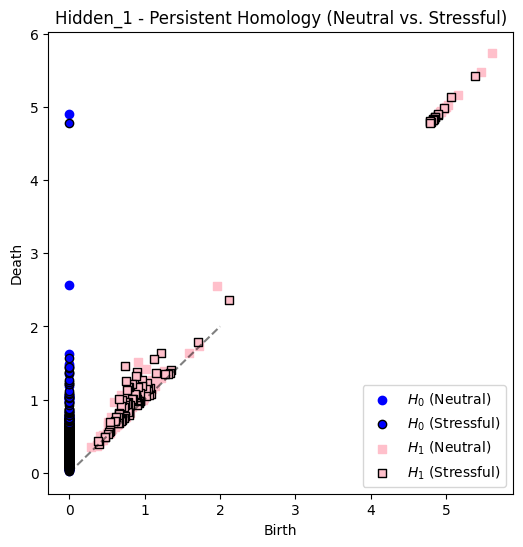

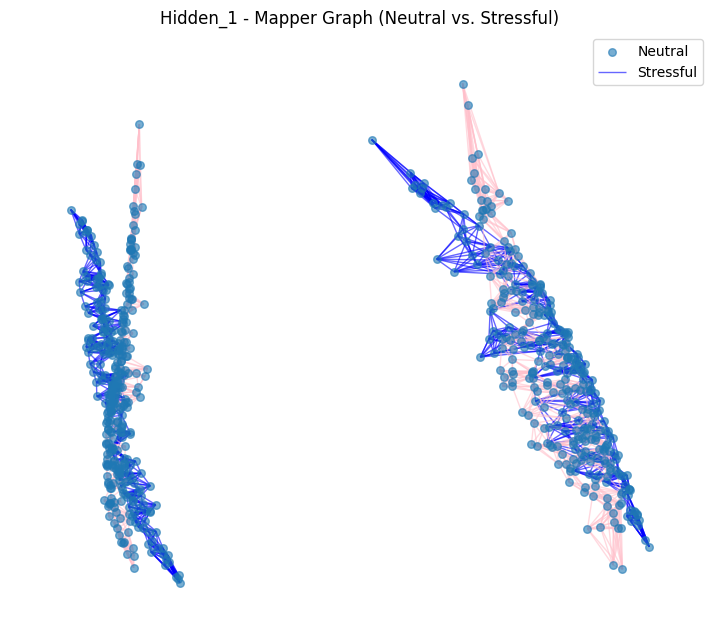

Analyzing Hidden_2 activations...


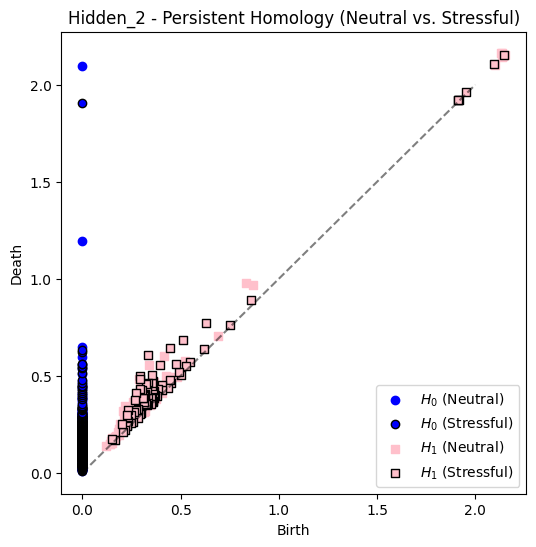

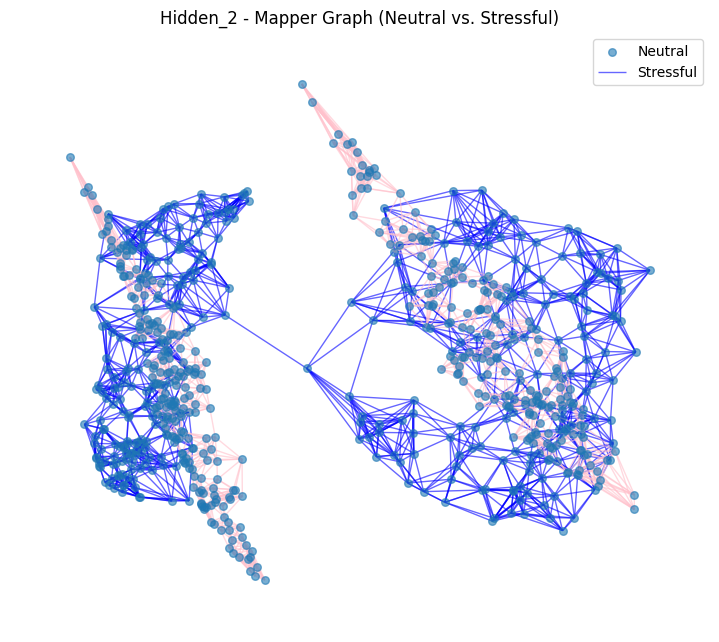

In [23]:
activations_neutral = extract_activations_gadget(ff_uncertain_gadget, X_neutral_test)
activations_stress = extract_activations_gadget(ff_uncertain_gadget, X_stress_test)

for key in activations_neutral.keys():
    print(f"Analyzing {key} activations...")

    act_neutral = activations_neutral[key]
    act_stress = activations_stress[key]

    compute_persistent_homology_overlay(act_neutral, act_stress, title=f"{key} - Persistent Homology (Neutral vs. Stressful)")

    compute_mapper_graph_overlay(act_neutral, act_stress, title=f"{key} - Mapper Graph (Neutral vs. Stressful)")

# Experiments

In [24]:
from analysis.analysis import (analyze_uncertainty_relationships,
                               simulate_lc_activation)

In [25]:
ff_uncertain_gadget

FFGadgetUncertainController(
  (fc1): Linear(in_features=7, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (lcne_gadget): LCNEGadgetCompositional(
    (W_LC1): Linear(in_features=256, out_features=256, bias=True)
    (W_LC2): Linear(in_features=256, out_features=256, bias=True)
    (tonic_control): Linear(in_features=256, out_features=256, bias=True)
    (phasic_control): Linear(in_features=256, out_features=256, bias=True)
    (adaptive_weight): Linear(in_features=256, out_features=256, bias=True)
    (uncertainty_gate): Linear(in_features=256, out_features=256, bias=True)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (tanh): Tanh()
    (sigmoid): Sigmoid()
  )
  (modulation_fc): Linear(in_features=512, out_features=256, bias=True)
  (Pupil_mean): Linear(in_features=256, out_features=1, bias=True)
  (Pupil_var): Linear(in_features=256, out_features=1, bias=True)
)

Adjusting prev_LC size: torch.Size([340, 256]) -> torch.Size([1699, 256])


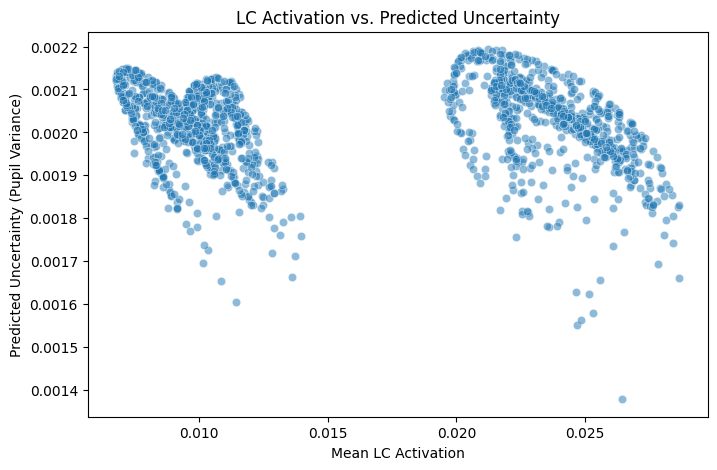

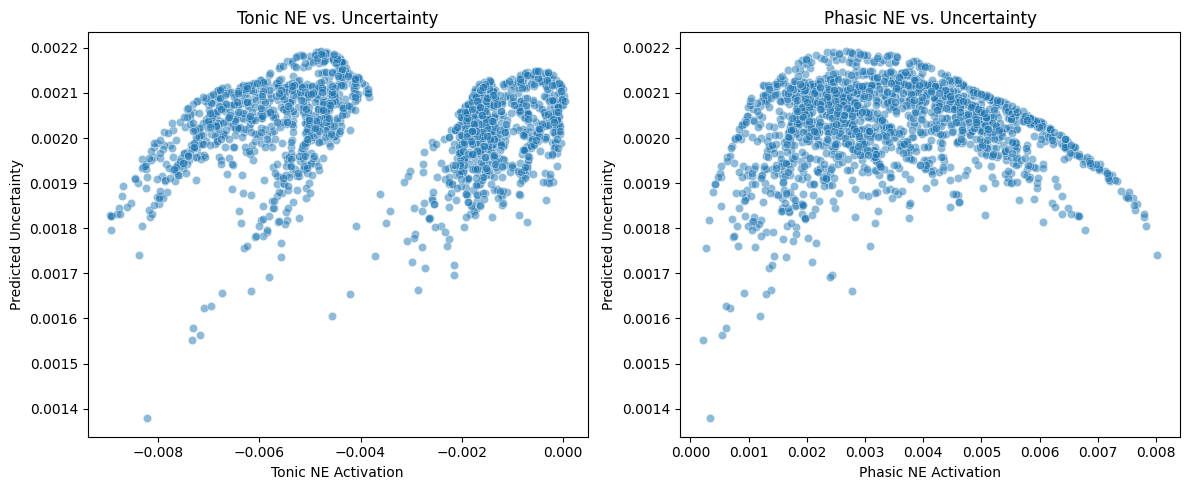


📊 **Correlation Results:**
LC vs. Uncertainty: -0.0525
Tonic NE vs. Uncertainty: 0.1040
Phasic NE vs. Uncertainty: 0.0205
NE vs. Uncertainty: -0.3019


In [26]:
uncertainty_results = analyze_uncertainty_relationships(ff_uncertain_gadget, X_tensor)

Adjusting prev_LC size: torch.Size([1699, 256]) -> torch.Size([340, 256])


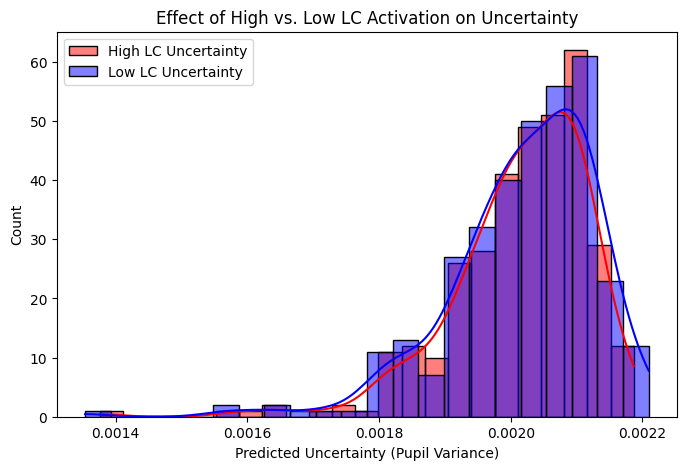

In [27]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.01)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()

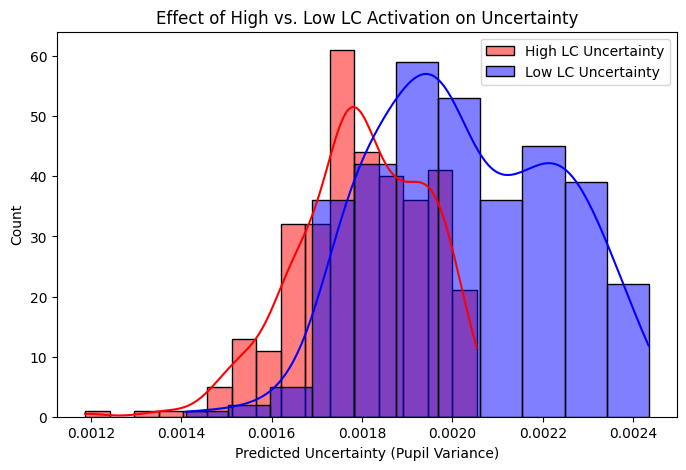

In [28]:
pupil_high, var_high, pupil_low, var_low = simulate_lc_activation(ff_uncertain_gadget, X_test, lc_boost=0.5)
plt.figure(figsize=(8,5))
sns.histplot(var_high.squeeze(), color="red", label="High LC Uncertainty", kde=True)
sns.histplot(var_low.squeeze(), color="blue", label="Low LC Uncertainty", kde=True)
plt.xlabel("Predicted Uncertainty (Pupil Variance)")
plt.title("Effect of High vs. Low LC Activation on Uncertainty")
plt.legend()
plt.show()